In [1]:
# ============================================================================
# Notebook 05 · Cell A — LLM bootstrap (.env only, no external manifest)
# ----------------------------------------------------------------------------
# Self-contained OpenAI client + caching cost tracker, adapted from the user's
# working llm_call(). Models are read from .env and mapped to weak/mid/strong
# tiers. Pricing is embedded here; "strong" has no public price, so its cost is
# logged as 0 and flagged.
#
# .env expected (project root or notebooks/ dir):
#   OPENAI_API_KEY=sk-...
#   LLM_MODEL_WEAK=gpt-4o-mini
#   LLM_MODEL_MID=gpt-5.4-mini
#   LLM_MODEL_STRONG=gpt-5.4
# ============================================================================
import os, re, json, time, hashlib, warnings
from pathlib import Path
from typing import Any
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from openai import OpenAI

# --- paths (this notebook lives in <PROJECT_ROOT>/notebooks/) ----------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE = PROJECT_ROOT / "artifacts" / "llm_cache"
CACHE.mkdir(parents=True, exist_ok=True)

SEED = 42

# --- load .env & build the model tier table ---------------------------------
load_dotenv(PROJECT_ROOT / ".env")
load_dotenv(Path.cwd() / ".env")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError("[ERROR] OPENAI_API_KEY not set in .env.")
client = OpenAI(api_key=OPENAI_API_KEY)

# Pricing (USD per 1M tokens); strong = unknown -> None
MODELS = {
    "weak":   {"name": os.getenv("LLM_MODEL_WEAK", "gpt-4o-mini"),
               "in": 0.15, "cached_in": 0.075, "out": 0.60},
    "mid":    {"name": os.getenv("LLM_MODEL_MID", "gpt-5.4-mini"),
               "in": 0.75, "cached_in": 0.075, "out": 4.50},
    "strong": {"name": os.getenv("LLM_MODEL_STRONG", "gpt-5.4"),
               "in": None, "cached_in": None, "out": None},
}
print("[INFO] model tiers:", {t: m["name"] for t, m in MODELS.items()})

class CostTracker:
    def __init__(self): self.records = []
    def add(self, tier, model, usage, tag=""):
        p = MODELS.get(tier, {})
        pin, pcached, pout = p.get("in"), p.get("cached_in"), p.get("out")
        pt = getattr(usage, "prompt_tokens", 0) or 0
        ct = getattr(usage, "completion_tokens", 0) or 0
        cached = 0
        det = getattr(usage, "prompt_tokens_details", None)
        if det is not None:
            cached = getattr(det, "cached_tokens", 0) or 0
        fresh = max(pt - cached, 0)
        cost = None
        if None not in (pin, pout):
            pc = pcached if pcached is not None else pin
            cost = (fresh * pin + cached * pc + ct * pout) / 1_000_000
        self.records.append({"tag": tag, "tier": tier, "model": model,
                             "prompt_tokens": pt, "cached_tokens": cached,
                             "completion_tokens": ct, "cost_usd": cost})
        return cost or 0.0
    def total_usd(self): return float(sum(r["cost_usd"] or 0.0 for r in self.records))

COST = CostTracker()

def _safe_json(text):
    if not text: return None
    t = re.sub(r"^```(?:json)?\s*|\s*```$", "", text.strip(), flags=re.S).strip()
    try: return json.loads(t)
    except Exception: pass
    for opener, closer in (("{", "}"), ("[", "]")):
        i, j = t.find(opener), t.rfind(closer)
        if 0 <= i < j:
            try: return json.loads(t[i:j+1])
            except Exception: continue
    return None

def _cache_key(model, system, user, temperature, response_json):
    raw = json.dumps({"m": model, "s": system, "u": user,
                      "t": temperature, "j": response_json},
                     ensure_ascii=False, sort_keys=True)
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()[:24]

def llm_call(system, user, tier="weak", temperature=0.0,
             response_json=True, tag="", use_cache=True, max_retries=3):
    """Cached chat call. Returns {text, json, cached, tier, model, cost_usd}."""
    model = MODELS[tier]["name"]
    key = _cache_key(model, system, user, temperature, response_json)
    cache_file = CACHE / f"{key}.json"
    if use_cache and cache_file.exists():
        c = json.loads(cache_file.read_text(encoding="utf-8"))
        c["cached"] = True
        original_cost = c.get("cost_usd", 0.0) or 0.0
        COST.records.append({"tag": tag or c.get("model", ""),
                             "tier": c.get("tier", tier), "model": c.get("model", ""),
                             "prompt_tokens": 0, "cached_tokens": 0,
                             "completion_tokens": 0, "cost_usd": original_cost})
        c["cost_usd"] = original_cost
        return c
    kwargs: dict[str, Any] = {
        "model": model,
        "messages": [{"role": "system", "content": system},
                     {"role": "user", "content": user}],
    }
    if response_json:
        kwargs["response_format"] = {"type": "json_object"}
    kwargs["temperature"] = temperature
    last_err = None
    for attempt in range(1, max_retries + 1):
        try:
            resp = client.chat.completions.create(**kwargs)
            text = resp.choices[0].message.content or ""
            parsed = _safe_json(text) if response_json else None
            if response_json and parsed is None:
                raise ValueError("Response was not valid JSON.")
            cost = COST.add(tier, model, resp.usage, tag=tag or model)
            out = {"text": text, "json": parsed, "cached": False,
                   "tier": tier, "model": model, "cost_usd": cost}
            if use_cache:
                cache_file.write_text(json.dumps(out, ensure_ascii=False), encoding="utf-8")
            return out
        except TypeError as e:
            if "temperature" in kwargs:
                kwargs.pop("temperature", None); last_err = e; continue
            last_err = e
        except Exception as e:
            last_err = e; time.sleep(min(2 ** attempt, 8))
    raise RuntimeError(f"[llm_call] failed after {max_retries} retries: {last_err}")

print("[INFO] llm_call() + CostTracker ready (nb 05).")

[INFO] model tiers: {'weak': 'gpt-4o-mini', 'mid': 'gpt-5.4-mini', 'strong': 'gpt-5.4'}
[INFO] llm_call() + CostTracker ready (nb 05).


In [2]:
# ============================================================================
# Notebook 05 · Cell B — Real-LLM compliance judgment (all tiers, en/local)
# ----------------------------------------------------------------------------
# Replaces the placeholder judge with a real llm_call()-backed judge. Runs each
# available tier over en/local and saves per-tier predictions. Requires Cell A.
# All outputs English-only; figures grayscale, no titles, dpi=600.
# ============================================================================
import os, re, json, random, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, seaborn as sns

RAW_DIR       = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
for _d in (PROCESSED_DIR, FIGURES_DIR, TABLES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

random.seed(SEED); np.random.seed(SEED)
matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="paper"); sns.set_palette("Greys_r")
FIG_DPI = 600; GREY_MID = "#777777"

def save_fig(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
    print(f"[save] figure {stem} (png, pdf)")

LABEL_NON = "NON_COMPLIANT"; LABEL_COMP = "COMPLIANT"; LABEL_OTHER = "OTHER"
VALID_LABELS = {LABEL_NON, LABEL_COMP, LABEL_OTHER}

# ---- case content loader (en/local) ----------------------------------------
def _find_case_zips():
    return [p for p in sorted(RAW_DIR.glob("*.zip")) if re.search(r"_03[._ ]", p.name)]
def load_case_content(ids):
    ids = set(ids); rows = []
    for zp in _find_case_zips():
        with zipfile.ZipFile(zp) as zf:
            for name in sorted(zf.namelist()):
                if not name.endswith(".json"): continue
                d = json.load(zf.open(name))
                _id = d.get("metadata", {}).get("id", "")
                if _id not in ids: continue
                c = (d.get("data", {}) or {}).get("content", {}) or {}
                rows.append({"id": _id, "content_en": c.get("en","") or "",
                             "content_local": c.get("local","") or ""})
    return pd.DataFrame(rows).sort_values("id").reset_index(drop=True)

# ---- build stratified eval set ---------------------------------------------
gold = pd.read_parquet(PROCESSED_DIR / "compliance_gold.parquet")
content = load_case_content(set(gold["id"]))
evalset = gold.merge(content, on="id", how="inner")
evalset = evalset[(evalset.content_en.str.len()>0) &
                  (evalset.content_local.str.len()>0)].reset_index(drop=True)
def stratified(df, by, n_per, seed=SEED):
    return (pd.concat([g.sample(n=min(n_per,len(g)), random_state=seed)
                       for _, g in df.groupby(by)])
            .sort_values("id").reset_index(drop=True))
eval_sample = stratified(evalset, ["country","label"], n_per=200)
print(f"[eval] stratified sample: {len(eval_sample):,}")

# ---- prompt + real-LLM judge ------------------------------------------------
# Note: the label is a proxy for "legal liability established" (see nb03), NOT
# "disclosure compliance". OTHER = principled abstention (mixed/unclear).
SYSTEM_PROMPT = (
    "You are a legal-compliance analyst. Given the text of a court/legal case, "
    "decide whether legal liability was established against the defendant. "
    "Respond ONLY as JSON: {\"label\": one of "
    "[\"NON_COMPLIANT\",\"COMPLIANT\",\"OTHER\"], \"confidence\": a number in "
    "[0,1]}. NON_COMPLIANT = liability/sanction established; COMPLIANT = no "
    "liability (dismissed/acquitted/exempted); OTHER = mixed or unclear. "
    "Judge only from the given text; do not use outside knowledge."
)
CHAR_LIMIT = 6000   # cap case text sent to the model (cost + context bound)

def predict_compliance(row, lang, tier):
    """Real LLM judgment. Returns (label, confidence). Cached by llm_call()."""
    text = (row["content_en"] if lang == "en" else row["content_local"])[:CHAR_LIMIT]
    user = f"CASE TEXT ({lang}):\n{text}\n\nReturn the JSON now."
    res = llm_call(SYSTEM_PROMPT, user, tier=tier, temperature=0.0,
                   response_json=True, tag=f"compliance-{tier}-{lang}")
    j = res.get("json") or {}
    label = str(j.get("label", "")).upper().strip()
    if label not in VALID_LABELS:
        label = LABEL_OTHER
    try:
        conf = float(j.get("confidence", 0.5))
    except (TypeError, ValueError):
        conf = 0.5
    conf = min(1.0, max(0.0, conf))
    return label, conf

# ---- run all available tiers -----------------------------------------------
TIERS = ["weak", "mid", "strong"]   # gpt-4o-mini / gpt-5.4-mini / gpt-5.4

def run_tier(tier):
    recs = []
    for _, r in eval_sample.iterrows():
        le, ce = predict_compliance(r, "en", tier)
        ll, cl = predict_compliance(r, "local", tier)
        recs.append({"id": r["id"], "country": r["country"], "gold": r["label"],
                     "pred_en": le, "conf_en": ce,
                     "pred_local": ll, "conf_local": cl})
    return pd.DataFrame(recs)

available = []
for tier in TIERS:
    model_name = MODELS[tier]["name"]
    try:  # connectivity probe: 1 cheap call; skip tier on failure
        _ = llm_call("ping", "Return JSON {\"ok\":true}.", tier=tier, tag=f"probe-{tier}")
    except Exception as e:
        print(f"[skip] tier '{tier}' ({model_name}) unavailable: {e}")
        continue
    pred_df = run_tier(tier)
    pred_df.to_parquet(PROCESSED_DIR / f"crosslingual_pred_{tier}.parquet", index=False)
    print(f"[{tier}:{model_name}] saved {len(pred_df):,} predictions")
    available.append(tier)

print(f"[cost] cumulative USD: {COST.total_usd():.4f}")
print(f"[done] Cell B complete; tiers with predictions: {available}")

[eval] stratified sample: 597
[weak:gpt-4o-mini] saved 597 predictions
[mid:gpt-5.4-mini] saved 597 predictions
[strong:gpt-5.4] saved 597 predictions
[cost] cumulative USD: 1.7174
[done] Cell B complete; tiers with predictions: ['weak', 'mid', 'strong']


  tier  coverage_en  coverage_local  sel_acc_en  sel_acc_local  sel_acc_gap  forced_acc_en  forced_acc_local  agreement  cohen_kappa  ECE_en  ECE_local
  weak       0.7303          0.7638      0.7500         0.7500       0.0000         0.5477            0.5729     0.8626       0.7861  0.1583     0.1553
   mid       0.5444          0.5444      0.7508         0.7385       0.0123         0.4087            0.4020     0.7605       0.6280  0.2123     0.2230
strong       0.4456          0.4221      0.7970         0.7857       0.0113         0.3551            0.3317     0.8677       0.7740  0.1623     0.1869
[save] figure fig05_coverage_selacc (png, pdf)


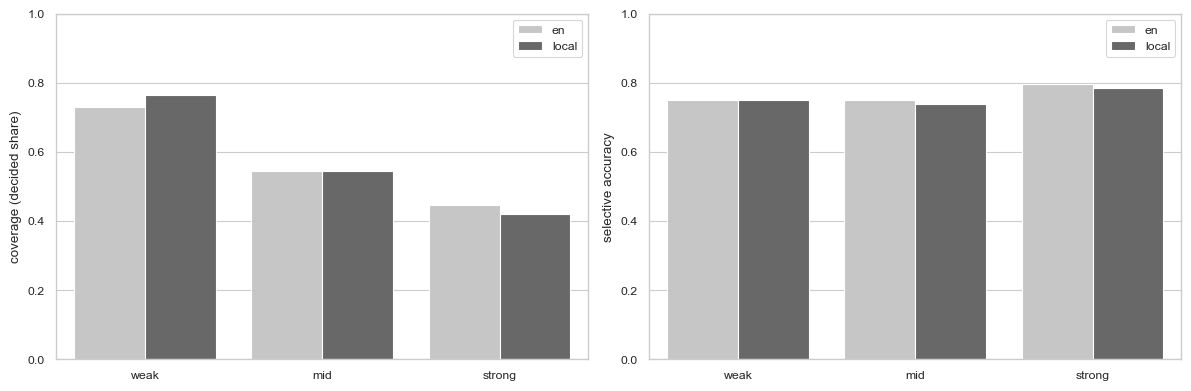


[done] Cell C complete.


In [3]:
# ============================================================================
# Notebook 05 · Cell C — Corrected metrics (coverage / selective accuracy)
# ----------------------------------------------------------------------------
# Re-scores the saved predictions (no new API calls) with a metric set suited
# to a 3-way judge (NON/COMP/OTHER) against a binary gold:
#   coverage           : share of items the model actually decided (not OTHER)
#   selective_accuracy : accuracy among decided items
#   forced_accuracy    : accuracy if OTHER is counted wrong (lower bound)
#   agreement / kappa  : en-local cross-lingual consistency
#   ECE                : calibration over decided items
# Requires Cell A (PROJECT_ROOT) and the parquet files written by Cell B.
# English-only outputs; grayscale figure, no titles, dpi=600.
# ============================================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, seaborn as sns

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
for _d in (FIGURES_DIR, TABLES_DIR): _d.mkdir(parents=True, exist_ok=True)

matplotlib.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="paper"); sns.set_palette("Greys_r")
FIG_DPI = 600; GREY_MID = "#777777"
def save_fig(fig, stem):
    for ext in ("png","pdf"):
        fig.savefig(FIGURES_DIR/f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
    print(f"[save] figure {stem} (png, pdf)")

OTHER = "OTHER"
def agreement(a,b):
    a,b=np.asarray(a),np.asarray(b); return float((a==b).mean()) if len(a) else 0.0
def cohen_kappa(a,b,labels):
    a,b=np.asarray(a),np.asarray(b); idx={l:i for i,l in enumerate(labels)}
    n,K=len(a),len(labels)
    if n==0: return 0.0
    conf=np.zeros((K,K))
    for x,y in zip(a,b):
        if x in idx and y in idx: conf[idx[x],idx[y]]+=1
    po=np.trace(conf)/n; r,c=conf.sum(1)/n,conf.sum(0)/n; pe=float((r*c).sum())
    return float((po-pe)/(1-pe)) if (1-pe)>1e-12 else 1.0
def ece(conf,correct,n_bins=10):
    conf,corr=np.asarray(conf,float),np.asarray(correct,float)
    if len(conf)==0: return 0.0
    bins=np.linspace(0,1,n_bins+1); e,n=0.0,len(conf)
    for i in range(n_bins):
        lo,hi=bins[i],bins[i+1]
        m=(conf>lo)&(conf<=hi) if i>0 else (conf>=lo)&(conf<=hi)
        if m.sum()==0: continue
        e+=(m.sum()/n)*abs(corr[m].mean()-conf[m].mean())
    return float(e)

def lang_metrics(p, lang):
    pred = p[f"pred_{lang}"]; gold = p["gold"]; conf = p[f"conf_{lang}"]
    decided = pred != OTHER
    cov = float(decided.mean())
    sel_acc = float((pred[decided]==gold[decided]).mean()) if decided.any() else 0.0
    forced_acc = float((pred==gold).mean())
    ece_dec = ece(conf[decided], (pred[decided]==gold[decided]).astype(int)) if decided.any() else 0.0
    return cov, sel_acc, forced_acc, ece_dec

rows = []
LABELS3 = ["NON_COMPLIANT","COMPLIANT","OTHER"]
for tier in ["weak","mid","strong"]:
    f = PROCESSED_DIR / f"crosslingual_pred_{tier}.parquet"
    if not f.exists(): continue
    p = pd.read_parquet(f)
    cov_en, sacc_en, facc_en, ece_en = lang_metrics(p, "en")
    cov_lo, sacc_lo, facc_lo, ece_lo = lang_metrics(p, "local")
    agr = agreement(p["pred_en"], p["pred_local"])
    kap = cohen_kappa(p["pred_en"].tolist(), p["pred_local"].tolist(), LABELS3)
    rows.append({
        "tier": tier,
        "coverage_en": round(cov_en,4), "coverage_local": round(cov_lo,4),
        "sel_acc_en": round(sacc_en,4), "sel_acc_local": round(sacc_lo,4),
        "sel_acc_gap": round(sacc_en - sacc_lo, 4),
        "forced_acc_en": round(facc_en,4), "forced_acc_local": round(facc_lo,4),
        "agreement": round(agr,4), "cohen_kappa": round(kap,4),
        "ECE_en": round(ece_en,4), "ECE_local": round(ece_lo,4),
    })

if not rows:
    print("[warn] no prediction parquet found; run Cell B first.")
else:
    mt = pd.DataFrame(rows)
    mt.to_csv(TABLES_DIR / "table05_crosslingual_corrected.csv",
              index=False, encoding="utf-8-sig")
    print(mt.to_string(index=False))

    # Figure: coverage (left) vs selective accuracy (right), en/local per model
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    cov_long = mt.melt(id_vars="tier", value_vars=["coverage_en","coverage_local"],
                       var_name="lang", value_name="coverage")
    cov_long["lang"] = cov_long["lang"].str.replace("coverage_","")
    sns.barplot(data=cov_long, x="tier", y="coverage", hue="lang",
                palette="Greys", ax=axes[0])
    axes[0].set_xlabel(""); axes[0].set_ylabel("coverage (decided share)")
    axes[0].set_ylim(0,1); axes[0].legend(title="")
    sacc_long = mt.melt(id_vars="tier", value_vars=["sel_acc_en","sel_acc_local"],
                        var_name="lang", value_name="sel_acc")
    sacc_long["lang"] = sacc_long["lang"].str.replace("sel_acc_","")
    sns.barplot(data=sacc_long, x="tier", y="sel_acc", hue="lang",
                palette="Greys", ax=axes[1])
    axes[1].set_xlabel(""); axes[1].set_ylabel("selective accuracy")
    axes[1].set_ylim(0,1); axes[1].legend(title="")
    fig.tight_layout(); save_fig(fig, "fig05_coverage_selacc"); plt.show()
    print("\n[done] Cell C complete.")